# Exploratory Data Analysis

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/global_tech_livability_dataset.csv")

In [47]:
# dataset shape
print("Shape:", df.shape)

# missing values
print(df.isnull().sum())

# duplicate rows
print("Duplicates:", df.duplicated().sum())

# data types and structure
df.info()

Shape: (24, 18)
City                            0
Country                         0
Air_Quality_Tier                0
Healthcare_Infrastructure       0
Green_Spaces_Recreation         0
Safety_Index_Score              0
Cost_of_Living_Index            0
Employment_Growth_Potential     0
Internet_Reliability            0
Education_Quality               0
Tech_Hub_Rating                 0
Public_Transport_Reliability    0
Climate_Type                    0
Popular_With                    0
Community_Vibe                  0
Migrant_Inflow_Rate             0
Overall_Livability_Score        0
Primary_Lifestyle_Vibe          0
dtype: int64
Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   City                          24 non-null     object
 1   Country                       24 non-null     object
 2   Air_Q

In [48]:
target = "Overall_Livability_Score"

# summary stats
df[target].describe()

count    24.000000
mean     77.041667
std      15.292735
min      35.000000
25%      72.250000
50%      82.500000
75%      86.500000
max      94.000000
Name: Overall_Livability_Score, dtype: float64

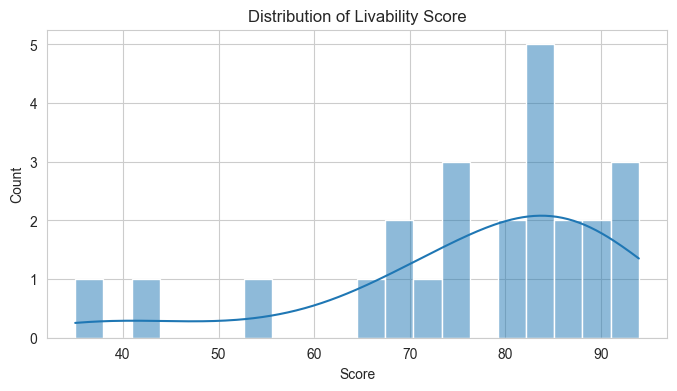

In [49]:
# distribution of target variable
plt.figure(figsize=(8, 4))

sns.histplot(df[target], kde=True, bins=20)

plt.title("Distribution of Livability Score")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()

In [50]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: ['Safety_Index_Score', 'Overall_Livability_Score']
Categorical columns: ['City', 'Country', 'Air_Quality_Tier', 'Healthcare_Infrastructure', 'Green_Spaces_Recreation', 'Cost_of_Living_Index', 'Employment_Growth_Potential', 'Internet_Reliability', 'Education_Quality', 'Tech_Hub_Rating', 'Public_Transport_Reliability', 'Climate_Type', 'Popular_With', 'Community_Vibe', 'Migrant_Inflow_Rate', 'Primary_Lifestyle_Vibe']


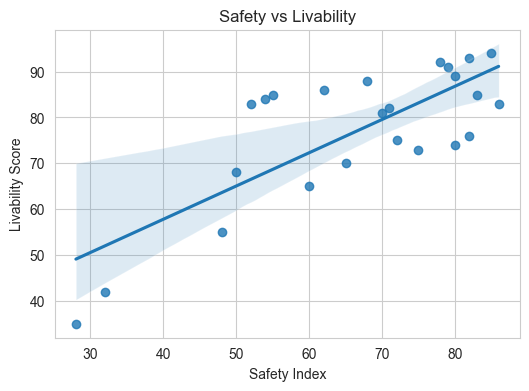

In [51]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x="Safety_Index_Score",
    y=target
)

plt.title("Safety vs Livability")
plt.xlabel("Safety Index")
plt.ylabel("Livability Score")

plt.show()

In [53]:
def plot_feature(feature):
    plt.figure(figsize=(8, 4))
    
    data = df.groupby(feature)[target].mean().sort_values()
    
    sns.barplot(
        x=data.values,
        y=data.index,
        palette="viridis"
    )
    
    plt.title(f"{feature} vs Livability")
    plt.xlabel("Average Livability Score")
    plt.ylabel(feature)
    
    plt.show()

/var/folders/w8/90t8tn0545gfwgnfspy0n4680000gn/T/ipykernel_38028/1607694813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


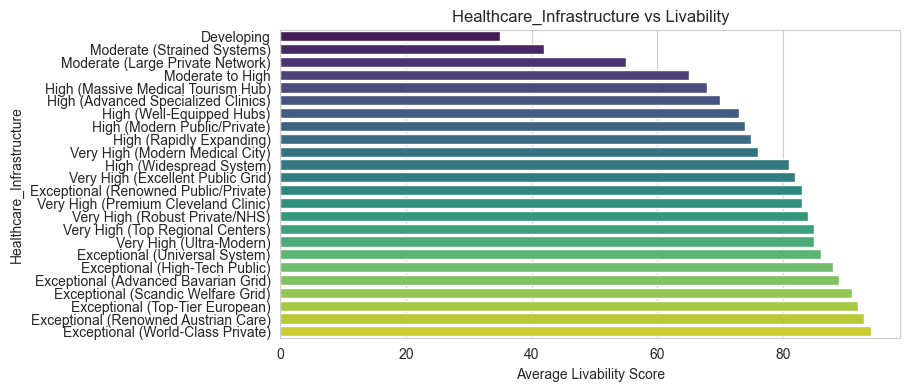

/var/folders/w8/90t8tn0545gfwgnfspy0n4680000gn/T/ipykernel_38028/1607694813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


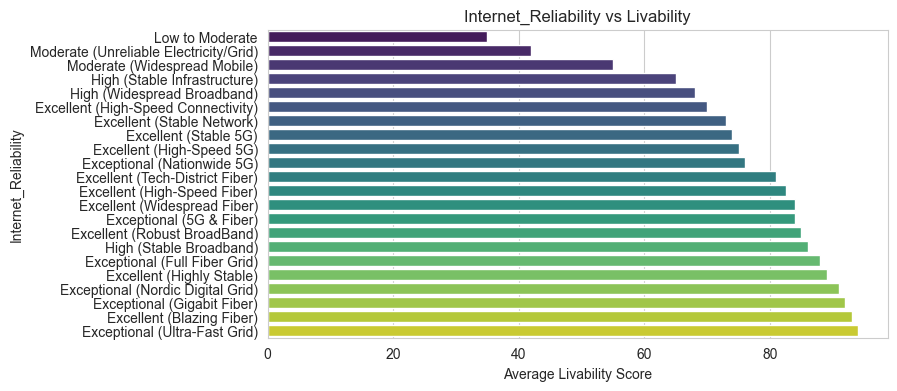

/var/folders/w8/90t8tn0545gfwgnfspy0n4680000gn/T/ipykernel_38028/1607694813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


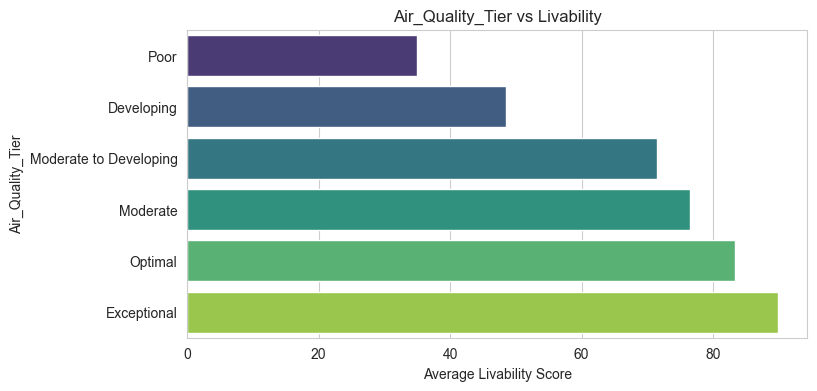

In [56]:
plot_feature("Healthcare_Infrastructure")
plot_feature("Internet_Reliability")
plot_feature("Air_Quality_Tier")

In [57]:
# Feature Impact Scoring
target = "Overall_Livability_Score"

impact = []

for col in df.select_dtypes(exclude=np.number).columns:
    if col == target:
        continue

    # mean livability per category
    means = df.groupby(col)[target].mean()

    impact.append({
        "feature": col,
        "num_categories": df[col].nunique(),
        "min_mean": means.min(),
        "max_mean": means.max(),
        "range": means.max() - means.min()
    })

impact_df = pd.DataFrame(impact)

# sort by strongest influence
impact_df.sort_values("range", ascending=False)

,feature,num_categories,min_mean,max_mean,range
0,City,24,35.0,94.000000,59.000000
1,Country,21,35.0,94.000000,59.000000
3,Healthcare_Infrastructure,24,35.0,94.000000,59.000000
4,Green_Spaces_Recreation,23,35.0,94.000000,59.000000
7,Internet_Reliability,22,35.0,94.000000,59.000000
6,Employment_Growth_Potential,24,35.0,94.000000,59.000000
9,Tech_Hub_Rating,24,35.0,94.000000,59.000000
8,Education_Quality,23,35.0,94.000000,59.000000
15,Primary_Lifestyle_Vibe,24,35.0,94.000000,59.000000
13,Community_Vibe,24,35.0,94.000000,59.000000


In [58]:
selected_features = [
    "Safety_Index_Score",
    "Air_Quality_Tier",
    "Healthcare_Infrastructure",
    "Internet_Reliability",
    "Education_Quality",
    "Public_Transport_Reliability",
    "Cost_of_Living_Index",
    "Tech_Hub_Rating",
    "Employment_Growth_Potential"
]

In [59]:
def encode_level(text):
    text = str(text).lower()

    if "exceptional" in text:
        return 5
    elif "very high" in text:
        return 4
    elif "high" in text:
        return 3
    elif "moderate" in text:
        return 2
    elif "low" in text or "developing" in text:
        return 1
    else:
        return 0

In [60]:
for col in selected_features:
    if col != "Safety_Index_Score":
        df[col + "_score"] = df[col].apply(encode_level)

In [61]:
model_df = df[["Overall_Livability_Score"]].copy()

for col in selected_features:
    if col == "Safety_Index_Score":
        model_df[col] = df[col]
    else:
        model_df[col + "_score"] = df[col + "_score"]

In [62]:
model_df.corr()

,Overall_Livability_Score,Safety_Index_Score,Air_Quality_Tier_score,Healthcare_Infrastructure_score,Internet_Reliability_score,Education_Quality_score,Public_Transport_Reliability_score,Cost_of_Living_Index_score,Tech_Hub_Rating_score,Employment_Growth_Potential_score
Overall_Livability_Score,1.000000,0.773142,0.440668,0.921512,0.232471,0.673814,0.705639,0.797983,0.756930,0.654338
Safety_Index_Score,0.773142,1.000000,0.437007,0.623410,0.325413,0.229939,0.273635,0.568055,0.334468,0.502952
Air_Quality_Tier_score,0.440668,0.437007,1.000000,0.405411,0.342748,0.445522,0.249671,0.463666,0.329371,0.168325
Healthcare_Infrastructure_score,0.921512,0.623410,0.405411,1.000000,0.382693,0.752184,0.781867,0.782439,0.735516,0.480943
Internet_Reliability_score,0.232471,0.325413,0.342748,0.382693,1.000000,0.108885,0.118520,0.341255,0.189202,0.207012
Education_Quality_score,0.673814,0.229939,0.445522,0.752184,0.108885,1.000000,0.798481,0.578771,0.690987,0.316613
Public_Transport_Reliability_score,0.705639,0.273635,0.249671,0.781867,0.118520,0.798481,1.000000,0.577671,0.633122,0.324831
Cost_of_Living_Index_score,0.797983,0.568055,0.463666,0.782439,0.341255,0.578771,0.577671,1.000000,0.699866,0.522039
Tech_Hub_Rating_score,0.756930,0.334468,0.329371,0.735516,0.189202,0.690987,0.633122,0.699866,1.000000,0.665994
Employment_Growth_Potential_score,0.654338,0.502952,0.168325,0.480943,0.207012,0.316613,0.324831,0.522039,0.665994,1.000000


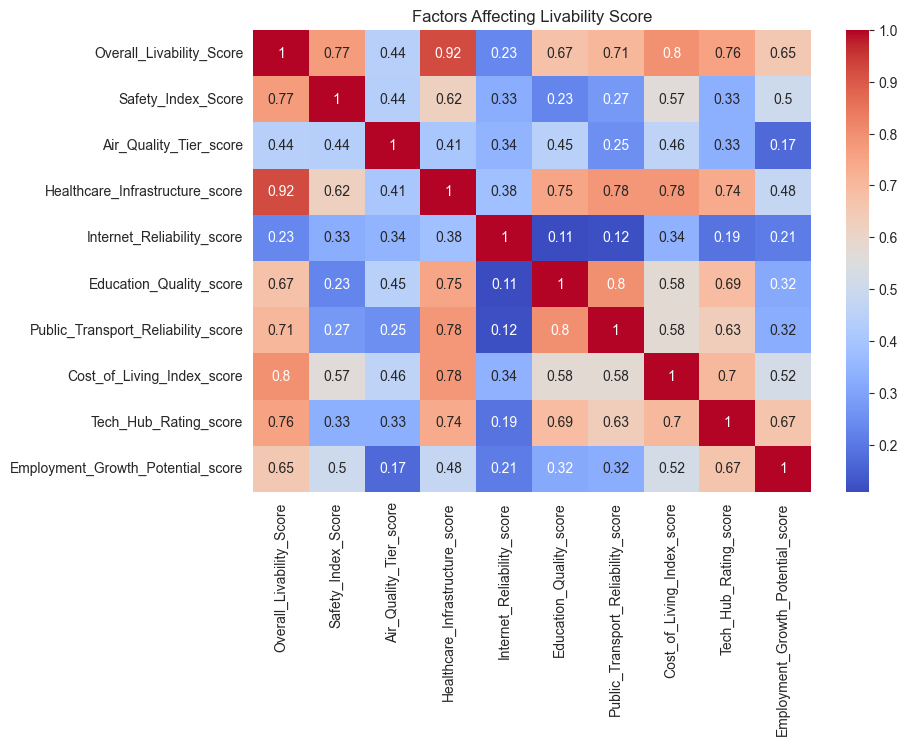

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

sns.heatmap(model_df.corr(), annot=True, cmap="coolwarm")

plt.title("Factors Affecting Livability Score")
plt.show()